# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1619s 9us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

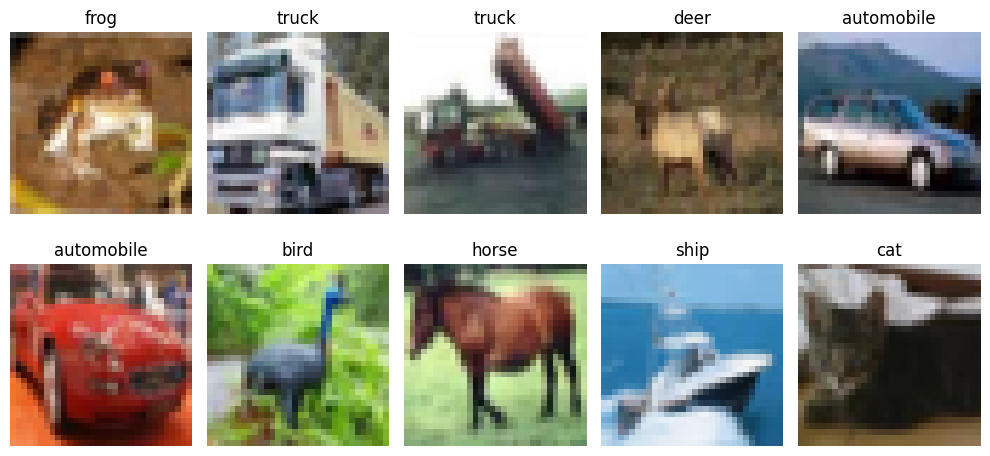

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.2678 - loss: 1.9995 - val_accuracy: 0.3384 - val_loss: 1.8334
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3170 - loss: 1.8702 - val_accuracy: 0.3446 - val_loss: 1.8143
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3376 - loss: 1.8226 - val_accuracy: 0.3906 - val_loss: 1.7372
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.3521 - loss: 1.7779 - val_accuracy: 0.3844 - val_loss: 1.7384
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.3625 - loss: 1.7479 - val_accuracy: 0.3844 - val_loss: 1.7394
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3710 - loss: 1.7291 - val_accuracy: 0.3922 - val_loss: 1.7085
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3766 - loss: 1.7129 - val_accuracy: 0.4184 - val_loss: 1.6614
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3820 - loss: 1.7000 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4166 - loss: 1.6299
ANN Test Accuracy: 0.41659998893737793


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 127ms/step - accuracy: 0.4607 - loss: 1.5129 - val_accuracy: 0.5528 - val_loss: 1.2486
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 127ms/step - accuracy: 0.6018 - loss: 1.1437 - val_accuracy: 0.6224 - val_loss: 1.1017
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 126ms/step - accuracy: 0.6666 - loss: 0.9615 - val_accuracy: 0.6158 - val_loss: 1.0606
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.7065 - loss: 0.8416 - val_accuracy: 0.6968 - val_loss: 0.8836
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.7444 - loss: 0.7408 - val_accuracy: 0.6736 - val_loss: 0.9746
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.7718 - loss: 0.6579 - val_accuracy: 0.6466 - val_loss: 1.1773
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.7945 - loss: 0.5849 - val_accuracy: 0.7044 - val_loss: 0.8997
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.8123 - loss: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7117 - loss: 0.9707
CNN Test Accuracy: 0.7117000222206116


## 📈 Compare Learning Curves

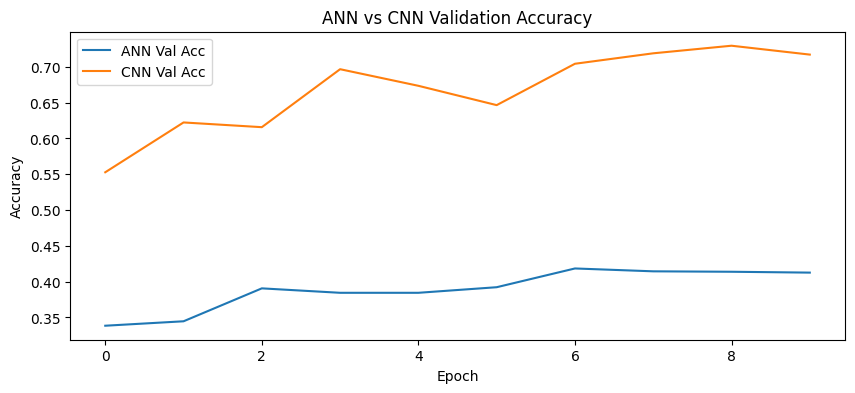

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4166
1,CNN,0.7117


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# 1. Increase ANN layers and observe performance

In [12]:
ann_deep_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_deep_history = ann_deep_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_deep_test_loss, ann_deep_test_acc = ann_deep_model.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", ann_deep_test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 66ms/step - accuracy: 0.2499 - loss: 2.0292 - val_accuracy: 0.3310 - val_loss: 1.8623
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.3101 - loss: 1.8806 - val_accuracy: 0.3300 - val_loss: 1.8297
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 66ms/step - accuracy: 0.3291 - loss: 1.8339 - val_accuracy: 0.3712 - val_loss: 1.7729
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3492 - loss: 1.7945 - val_accuracy: 0.3872 - val_loss: 1.7282
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3582 - loss: 1.7630 - val_accuracy: 0.3956 - val_loss: 1.7060
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.3672 - loss: 1.7412 - val_accuracy: 0.3904 - val_loss: 1.6983
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.3788 - loss: 1.7214 - val_accuracy: 0.4080 - val_loss: 1.6820
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.3797 - loss: 1.7103 - 

# 2. Change CNN filters from 32→64→128

In [13]:
cnn_scaled_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_scaled_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_scaled_history = cnn_scaled_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_scaled_test_loss, cnn_scaled_test_acc = cnn_scaled_model.evaluate(x_test_norm, y_test)
print("Scaled-filter CNN Test Accuracy:", cnn_scaled_test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 197ms/step - accuracy: 0.4448 - loss: 1.5600 - val_accuracy: 0.5282 - val_loss: 1.3315
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 194ms/step - accuracy: 0.5862 - loss: 1.1663 - val_accuracy: 0.6520 - val_loss: 0.9718
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 203ms/step - accuracy: 0.6547 - loss: 0.9882 - val_accuracy: 0.6470 - val_loss: 1.0024
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.6979 - loss: 0.8611 - val_accuracy: 0.7022 - val_loss: 0.8484
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 199ms/step - accuracy: 0.7328 - loss: 0.7654 - val_accuracy: 0.7296 - val_loss: 0.7995
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.7605 - loss: 0.6844 - val_accuracy: 0.7020 - val_loss: 0.8968
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 200ms/step - accuracy: 0.7826 - loss: 0.6189 - val_accuracy: 0.6848 - val_loss: 0.9238
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.8004 -

# 3. Increase epochs to 20

In [14]:
cnn_20ep_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20ep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20ep_history = cnn_20ep_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_20ep_test_loss, cnn_20ep_test_acc = cnn_20ep_model.evaluate(x_test_norm, y_test)
print("CNN (20 epochs) Test Accuracy:", cnn_20ep_test_acc)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 124ms/step - accuracy: 0.4680 - loss: 1.5003 - val_accuracy: 0.5630 - val_loss: 1.2174
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 126ms/step - accuracy: 0.6067 - loss: 1.1228 - val_accuracy: 0.6570 - val_loss: 0.9791
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 126ms/step - accuracy: 0.6678 - loss: 0.9587 - val_accuracy: 0.5284 - val_loss: 1.5754
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7044 - loss: 0.8442 - val_accuracy: 0.4320 - val_loss: 2.4851
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 128ms/step - accuracy: 0.7373 - loss: 0.7487 - val_accuracy: 0.6696 - val_loss: 0.9766
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 126ms/step - accuracy: 0.7644 - loss: 0.6715 - val_accuracy: 0.6946 - val_loss: 0.9182
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7890 - loss: 0.6066 - val_accuracy: 0.7100 - val_loss: 0.8878
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 127ms/step - accuracy: 0.8080 - loss

# 4. Add EarlyStopping

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

cnn_es_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_es_history = cnn_es_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_test_loss, cnn_es_test_acc = cnn_es_model.evaluate(x_test_norm, y_test)
print("CNN + EarlyStopping Test Accuracy:", cnn_es_test_acc)
print("Stopped at epoch:", len(cnn_es_history.history['loss']))


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 125ms/step - accuracy: 0.4757 - loss: 1.4655 - val_accuracy: 0.5488 - val_loss: 1.2649
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.6219 - loss: 1.0879 - val_accuracy: 0.6024 - val_loss: 1.1243
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 126ms/step - accuracy: 0.6797 - loss: 0.9205 - val_accuracy: 0.6266 - val_loss: 1.0500
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 126ms/step - accuracy: 0.7232 - loss: 0.7997 - val_accuracy: 0.7138 - val_loss: 0.8431
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 126ms/step - accuracy: 0.7509 - loss: 0.7096 - val_accuracy: 0.6938 - val_loss: 0.9085
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.7758 - loss: 0.6348 - val_accuracy: 0.7160 - val_loss: 0.8887
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 127ms/step - accuracy: 0.8015 - loss: 0.5652 - val_accuracy: 0.6506 - val_loss: 1.1958
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6943 - loss: 0.8835
CNN +

# 5. Add data augmentation training

In [16]:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 95ms/step - accuracy: 0.3576 - loss: 1.7621 - val_accuracy: 0.4940 - val_loss: 1.4000
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.4569 - loss: 1.5079 - val_accuracy: 0.5082 - val_loss: 1.3797
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 94ms/step - accuracy: 0.4913 - loss: 1.4198 - val_accuracy: 0.5550 - val_loss: 1.2360
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5161 - loss: 1.3609 - val_accuracy: 0.5608 - val_loss: 1.2253
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.5289 - loss: 1.3199 - val_accuracy: 0.6004 - val_loss: 1.1292
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.5472 - loss: 1.2807 - val_accuracy: 0.6090 - val_loss: 1.0907
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.5534 - loss: 1.2553 - val_accuracy: 0.6202 - val_loss: 1.0921
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 94ms/step - accuracy: 0.5664 - loss: 1.2330 - 

# Final Comparison

In [17]:
comparison_final = pd.DataFrame({
    "Model": ["ANN (baseline)", "CNN (baseline)", "ANN (deeper)",
              "CNN (scaled filters)", "CNN (20 epochs)",
              "CNN (EarlyStopping)", "CNN (augmented)"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, ann_deep_test_acc,
                       cnn_scaled_test_acc, cnn_20ep_test_acc,
                       cnn_es_test_acc, aug_test_acc]
})
comparison_final


,Model,Test Accuracy
0,ANN (baseline),0.4166
1,CNN (baseline),0.7117
2,ANN (deeper),0.4278
3,CNN (scaled filters),0.7273
4,CNN (20 epochs),0.7114
5,CNN (EarlyStopping),0.6943
6,CNN (augmented),0.6286


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**